# 03 · FlashAttention

> 接着 02 的 Online Softmax，学习 2022 论文中的分块计算和反向重计算，再用 SDPA 测量本机的延迟和显存。第 6 节是 FlashAttention-2 的后续拓展，不属于这篇 NeurIPS 2022 论文。

**目录**
1. [IO 复杂度分析](#1-IO-复杂度分析)
2. [分块前向算法](#2-分块前向算法)
3. [PyTorch SDPA 接口](#3-PyTorch-SDPA-接口)
4. [基准测试](#4-基准测试)
5. [反向传播：重计算策略](#5-反向传播重计算策略)
6. [拓展：FlashAttention-2](#6-拓展flashattention-2)
7. [小结](#7-小结)

---

In [1]:
import platform
import sys
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
print(f"运行系统: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")

import math
import json
import inspect
from contextlib import contextmanager
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch: {torch.__version__}")
print(f"运行设备: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}，显存 {props.total_memory / 1e9:.1f} GB")

try:
    from torch.nn.attention import SDPBackend, sdpa_kernel
except ImportError:
    SDPBackend = None

@contextmanager
def select_backend(name):
    if name not in ("math", "flash"):
        raise ValueError("backend 请选择 'math' 或 'flash'")
    if SDPBackend is not None:
        backend = {"math": SDPBackend.MATH, "flash": SDPBackend.FLASH_ATTENTION}[name]
        with sdpa_kernel(backend):
            yield
    else:
        options = dict(enable_flash=name == "flash", enable_math=name == "math",
                       enable_mem_efficient=False)
        if "enable_cudnn" in inspect.signature(torch.backends.cuda.sdp_kernel).parameters:
            options["enable_cudnn"] = False
        with torch.backends.cuda.sdp_kernel(**options):
            yield

class FlashUnavailable(RuntimeError):
    """当前 PyTorch 或输入无法使用指定的 Flash backend。"""

def run_standard(Q, K, V, causal=False):
    with select_backend("math"):
        return F.scaled_dot_product_attention(Q, K, V, is_causal=causal, dropout_p=0.0)

def run_flash(Q, K, V, causal=False):
    is_compiled = getattr(torch.backends.cuda, "is_flash_attention_available", None)
    if Q.device.type == "cuda" and is_compiled is not None and not is_compiled():
        raise FlashUnavailable("当前 PyTorch 没有编译 CUDA FlashAttention")
    try:
        with select_backend("flash"):
            return F.scaled_dot_product_attention(Q, K, V, is_causal=causal, dropout_p=0.0)
    except RuntimeError as exc:
        if any(message in str(exc).lower() for message in
               ("no available kernel", "no viable backend")):
            raise FlashUnavailable(str(exc)) from exc
        raise

运行系统: Linux 6.6.87.2-microsoft-standard-WSL2
Python: 3.10.12


PyTorch: 2.11.0+cu128
运行设备: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU，显存 8.6 GB


## 1 IO 复杂度分析

沿用前两节的符号：序列长度为 $N$，每头维度为 $d_k$，批次大小为 $B$，头数为 $h$。这里先分析单样本、单头，令 $Q,K,V\in\mathbb{R}^{N\times d_k}$：
$$
S=\frac{QK^\top}{\sqrt{d_k}},\qquad A=\text{softmax}(S),\qquad O=AV.
$$
Softmax 沿每行计算。本节不使用 dropout，且 $Q,K,V$ 的形状相同。

论文讨论的 GPU 用 HBM 保存大张量，用容量较小的片上 SRAM 复用当前块。其他 GPU 也可能使用 GDDR 显存，这里沿用论文的 HBM/SRAM 两级存储模型。本节的 IO 复杂度统计数据在两者之间搬运的元素数。

### 1.1 标准注意力的 HBM 读写

与 01 一样，先按各阶段的输入和输出估算，不计矩阵乘内部的重复读取：

| 阶段 | 读 | 写 |
|------|----|----|
| $S=QK^\top/\sqrt{d_k}$ | $2Nd_k$ | $N^2$ |
| $A=\text{softmax}(S)$ | $N^2$ | $N^2$ |
| $O=AV$ | $N^2+Nd_k$ | $Nd_k$ |
| 合计 | $2N^2+3Nd_k$ | $2N^2+Nd_k$ |

合计为 $\Theta(Nd_k+N^2)$。当 $N\gg d_k$ 时，保存和读取 $S,A$ 是主要开销。

### 1.2 块大小怎么选？

FlashAttention 把 $Q$ 分成 $B_r$ 行的块，把 $K,V$ 分成 $B_c$ 行的块。只计算当前分数块 $S_{ij}$，用 02 的 Online Softmax 更新 $(m,\ell,O)$，用完就丢弃分数块。

设 SRAM 可容纳 $M$ 个元素。需要同时放下 $Q_i,O_i,K_j,V_j$、局部分数或指数块，以及行统计量：
$$
\text{片上工作空间}=O(B_r d_k+B_c d_k+B_rB_c+B_r).
$$
其中 $B_rB_c$ 是当前分数块的大小，也要计入容量。两个块不必一样大；实现时还要考虑缓冲区复用、寄存器和临时空间。

论文 Algorithm 1 采用：
$$
B_c=\left\lceil\frac{M}{4d_k}\right\rceil,\qquad
B_r=\min(B_c,d_k).
$$
由于 $B_r\le d_k$，有 $B_rB_c\le d_kB_c$，因此每项都是 $O(M)$。由此得到 $B_c=\Theta(M/d_k)$。这是数量级估算，实际选择还要按数据类型换算成字节，并留出临时空间。这里的 $M$ 指当前计算可用的片上空间。

在这个模型里，增大 $B_c$ 能减少 $K/V$ 块数，也就减少整遍读取 $Q,O$ 的次数。实际块大小还受寄存器、共享内存、矩阵乘指令和并行度限制，需要针对设备调优。

### 1.3 FlashAttention 的 HBM 读写

Algorithm 1 外层遍历 $K/V$ 块，内层遍历 $Q$ 块。记
$$
T_c=\lceil N/B_c\rceil,\qquad T_r=\lceil N/B_r\rceil.
$$

- $K,V$ 各读取一遍，共 $2Nd_k$ 个元素。
- 每个 $K/V$ 块都要读取一遍 $Q$，并读写 $O,m,\ell$，共 $\Theta(Nd_k)$ 个元素。
- $S_{ij}$ 和局部指数块在片上计算，不写回 HBM。

所以总访问量为：
$$
\Theta(Nd_k+T_cNd_k)
=\Theta\!\left(Nd_k+\frac{N^2d_k^2}{M}\right).
$$
在论文分析的 $d_k\le M\le Nd_k$ 范围内，可写为 $\Theta(N^2d_k^2/M)$。当 $N\gg d_k$ 且 $M\gg d_k^2$ 时，相比标准实现的主项，访问量约减少 $M/d_k^2$ 倍（忽略常数）。这不是延迟加速比。

注意 IO 公式里出现的是 $d_k^2$。全注意力的计算量仍为 $\Theta(N^2d_k)$。

$O(\cdot)$ 表示增长的上界，$\Theta(\cdot)$ 表示这里分析得到的增长量级。论文的结论主要比较搬运多少元素，并不直接给出某张 GPU 上的运行时间。

来源：[本地 FlashAttention 论文](https://arxiv.org/abs/2205.14135)，第 5 页 Algorithm 1、Theorem 2。

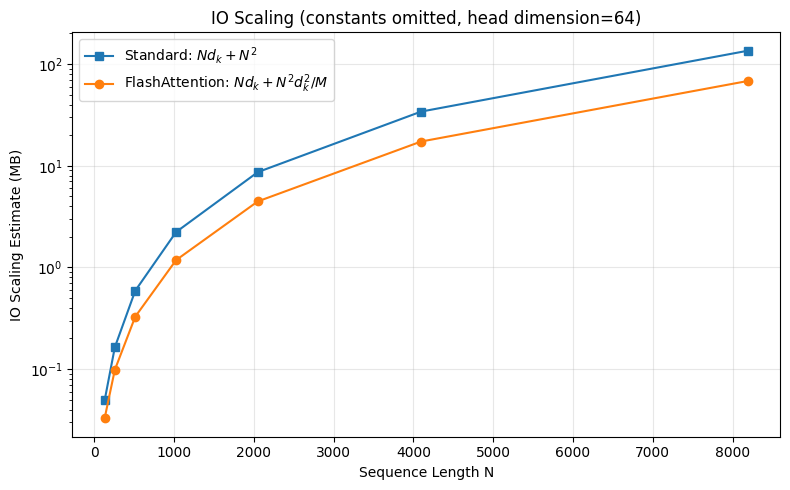

In [2]:
# 同一数据类型下的 IO 数量级示意，不是硬件访问量实测
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192]
d_k = 64
M = 8_192  # 可容纳的元素数；所有 N 均满足 d_k <= M <= N*d_k
bytes_per_element = 2
standard_io = np.array([N * d_k + N**2 for N in seq_lens])
flash_io = np.array([N * d_k + N**2 * d_k**2 / M for N in seq_lens])

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(seq_lens, standard_io * bytes_per_element / 1e6,
            marker='s', label=r'Standard: $Nd_k+N^2$')
ax.semilogy(seq_lens, flash_io * bytes_per_element / 1e6,
            marker='o', label=r'FlashAttention: $Nd_k+N^2d_k^2/M$')
ax.set_xlabel('Sequence Length N')
ax.set_ylabel('IO Scaling Estimate (MB)')
ax.set_title(f'IO Scaling (constants omitted, head dimension={d_k})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "03_io_complexity.png", dpi=120, bbox_inches='tight')
plt.show()

**图像分析**

两条曲线都随序列长度增加而上升，但 FlashAttention 的估算访问量更低。例如，在本图的参数下，$N=8192$ 时，标准方法约为 135.27 MB，FlashAttention 约为 68.16 MB，接近前者的一半。这说明分块复用数据有助于减少显存读写。

这里的数值由公式计算，并省略了常数，属于理论示意。固定本图的头维度和片上容量后，两条曲线仍包含随 $N^2$ 增长的项，因此不能理解为 FlashAttention 将计算量降成了线性，也不能把访问量减少的比例直接当成加速比。

## 2 分块前向算法

先把 02 的块级更新放进两层循环。外层取一块 $K,V$，内层依次更新各个 $Q$ 块。为方便对照前两节，论文中的头维度 $d$ 和注意力权重 $P$ 在这里记为 $d_k$ 和 $A$。

$i,j$ 是块编号。$\tilde A_{ij}$ 只是当前块的指数值，还没有按整行归一化。$m,\ell$ 每行各有一个值，代码用 `unsqueeze(-1)` 把行缩放系数广播到所有列。

下面按 2022 论文 Algorithm 1 写出无掩码、无 dropout 的前向流程。代码再补上因果掩码和空行处理；没有实现论文的 dropout 分支。

```text
输入：Q, K, V，形状均为 (N, d_k)，存于 HBM
1. 选择 Br, Bc，计算 Tr = ceil(N/Br)，Tc = ceil(N/Bc)
2. 在 HBM 初始化 O = 0，ℓ = 0，m = -∞，并按 Q 的行分块
3. for j = 1, ..., Tc:
4.     从 HBM 加载 Kj, Vj 到 SRAM
5.     for i = 1, ..., Tr:
6.         从 HBM 加载 Qi, Oi, ℓi, mi 到 SRAM
7.         Sij = Qi Kjᵀ / sqrt(d_k)
8.         m̃ij = rowmax(Sij)
9.         Ãij = exp(Sij - m̃ij)，ℓ̃ij = rowsum(Ãij)
10.        mi_new = max(mi, m̃ij)
11.        α = exp(mi - mi_new)，β = exp(m̃ij - mi_new)
12.        ℓi_new = α ℓi + β ℓ̃ij
13.        Oi_new = (α ℓi Oi + β Ãij Vj) / ℓi_new
14.        将 Oi_new, ℓi_new, mi_new 写回 HBM
输出：O
```

第 7–13 步在片上完成，第 14 步只写回输出和行统计量。初始化也需要 $O(Nd_k)$ 的写入。每个内层步骤读取约 $2B_rd_k+2B_r$、写入约 $B_rd_k+2B_r$ 个元素。

02 的 `tiled_online_attention` 用的就是这组更新公式。下面除了输出，还返回 $\ell,m$，供第 5 节重算注意力权重。因果模式下，完全位于未来的块直接跳过；跨过对角线的块再逐元素遮蔽。

这是便于阅读的 PyTorch 实现。真实 FlashAttention 把这些操作合进 kernel，让中间块留在片上；普通张量切片无法保证这一点。这里可以用 autograd 检查梯度，但计算图仍会保存中间结果。第 5 节会单独演示重计算的反向公式。

FP16/BF16 输入在这份示例里先整体转成 FP32，矩阵乘和累积都用 FP32，最后把输出转回输入类型。这与真实 Flash kernel 的低精度矩阵乘、FP32 累积不同，也会增加转换开销。

In [3]:
def validate_attention_inputs(Q, K, V, block_r, block_c):
    if any(type(size) is not int or size <= 0 for size in (block_r, block_c)):
        raise ValueError("block_r 和 block_c 必须是正整数")
    if Q.ndim != 4 or Q.shape != K.shape or Q.shape != V.shape or min(Q.shape) == 0:
        raise ValueError("Q、K、V 的形状应相同，且为非空的 (B,h,N,d_k)")
    if Q.dtype not in (torch.float16, torch.bfloat16, torch.float32, torch.float64):
        raise ValueError("本例支持 FP16、BF16、FP32 和 FP64")
    if K.dtype != Q.dtype or V.dtype != Q.dtype:
        raise ValueError("Q、K、V 应使用相同的数据类型")
    if K.device != Q.device or V.device != Q.device:
        raise ValueError("Q、K、V 应在同一设备上")

def block_scores(Qi, Kj, i0, j0, scale, causal):
    Sij = (Qi @ Kj.transpose(-2, -1)) * scale
    if causal and j0 + Kj.size(-2) - 1 > i0:
        q_pos = torch.arange(i0, i0 + Qi.size(-2), device=Qi.device)[:, None]
        k_pos = torch.arange(j0, j0 + Kj.size(-2), device=Qi.device)[None, :]
        Sij = Sij.masked_fill(k_pos > q_pos, float("-inf"))
    return Sij

def block_statistics(Sij):
    m_tilde = Sij.amax(dim=-1)
    # 一行可能在当前块中没有可见 key；令其指数和为 0，避免 -inf - (-inf)。
    safe_max = torch.where(torch.isneginf(m_tilde), 0.0, m_tilde)
    A_tilde = torch.exp(Sij - safe_max.unsqueeze(-1))
    return m_tilde, A_tilde, A_tilde.sum(dim=-1)

def flash_attention_v1_forward(Q, K, V, block_r=64, block_c=64, causal=False):
    """按 K/V 块遍历，返回输出 O 和每行的 ell、m。"""
    validate_attention_inputs(Q, K, V, block_r, block_c)
    output_dtype = Q.dtype
    if Q.dtype in (torch.float16, torch.bfloat16):
        Q, K, V = Q.float(), K.float(), V.float()
    N, d_k = Q.shape[-2:]
    scale = 1 / math.sqrt(d_k)
    O = torch.zeros_like(Q)
    ell = Q.new_zeros(Q.shape[:-1])
    m = Q.new_full(Q.shape[:-1], float("-inf"))
    needs_grad = torch.is_grad_enabled() and any(x.requires_grad for x in (Q, K, V))

    for j0 in range(0, N, block_c):
        Kj, Vj = K[..., j0:j0 + block_c, :], V[..., j0:j0 + block_c, :]
        for i0 in range(0, N, block_r):
            i1 = min(i0 + block_r, N)
            if causal and j0 >= i1:
                continue
            Qi = Q[..., i0:i1, :]
            Oi, ell_i, mi = O[..., i0:i1, :], ell[..., i0:i1], m[..., i0:i1]
            # 后面会回写这些位置；有梯度时，先保留反向需要的旧值。
            if needs_grad:
                Oi, ell_i, mi = Oi.clone(), ell_i.clone(), mi.clone()

            Sij = block_scores(Qi, Kj, i0, j0, scale, causal)
            m_tilde, A_tilde, ell_tilde = block_statistics(Sij)
            mi_new = torch.maximum(mi, m_tilde)
            alpha = torch.exp(mi - mi_new)
            beta = torch.exp(m_tilde - mi_new)
            ell_new = alpha * ell_i + beta * ell_tilde
            O_new = ((alpha * ell_i).unsqueeze(-1) * Oi
                     + beta.unsqueeze(-1) * (A_tilde @ Vj)) / ell_new.unsqueeze(-1)

            O[..., i0:i1, :] = O_new
            ell[..., i0:i1] = ell_new
            m[..., i0:i1] = mi_new

    return O.to(output_dtype), ell, m

# N=65 会留下不足一整块的尾部；也检查 Br 与 Bc 不同的情况。
torch.manual_seed(42)
Qv = torch.randn(1, 2, 65, 32, device=device)
Kv, Vv = torch.randn_like(Qv), torch.randn_like(Qv)
with torch.no_grad():
    for causal in (False, True):
        reference = run_standard(Qv, Kv, Vv, causal)
        for block_r, block_c in [(8, 8), (16, 32), (32, 16), (64, 64), (128, 128)]:
            output, ell, m = flash_attention_v1_forward(Qv, Kv, Vv, block_r, block_c, causal)
            torch.testing.assert_close(output, reference, atol=1e-5, rtol=1e-4)
            assert (ell > 0).all() and torch.isfinite(m).all()
            error = (output - reference).abs().max().item()
            print(f"causal={causal}, Br={block_r:3d}, Bc={block_c:3d}: 最大误差 {error:.2e}")

causal=False, Br=  8, Bc=  8: 最大误差 5.36e-07
causal=False, Br= 16, Bc= 32: 最大误差 5.07e-07
causal=False, Br= 32, Bc= 16: 最大误差 3.43e-07
causal=False, Br= 64, Bc= 64: 最大误差 3.58e-07
causal=False, Br=128, Bc=128: 最大误差 3.87e-07


causal=True, Br=  8, Bc=  8: 最大误差 4.17e-07
causal=True, Br= 16, Bc= 32: 最大误差 4.47e-07
causal=True, Br= 32, Bc= 16: 最大误差 5.36e-07
causal=True, Br= 64, Bc= 64: 最大误差 4.77e-07
causal=True, Br=128, Bc=128: 最大误差 4.77e-07


**结果分析**

普通注意力和因果注意力的最大绝对误差都在 $3.4\times10^{-7}$ 到 $5.4\times10^{-7}$ 左右，且全部通过了代码中的误差检查。在这组 FP32 输入上，分块计算与标准方法的输出基本一致，支持前向更新公式实现正确。

本次序列长度为 65，既测试了不足一整块的尾部，也测试了行块和列块大小不同的情况。改变块大小后，误差没有明显地一直增大或减小，这种小幅变化可以从浮点运算顺序不同来理解。这里验证的是结果正确性，速度需要看后面的基准测试。

## 3 PyTorch SDPA 接口

实际使用时，可以先从 `F.scaled_dot_product_attention`（SDPA）开始。它会根据设备、数据类型、形状和掩码选择实现。

| Backend | 说明 |
|---------|------|
| `FLASH_ATTENTION` | FlashAttention 融合实现；CUDA 上常用于 FP16/BF16 |
| `EFFICIENT_ATTENTION` | 另一种节省显存的 CUDA 实现 |
| `CUDNN_ATTENTION` | cuDNN 提供的注意力实现 |
| `MATH` | 通用实现，本节用它作为数值基准 |

`torch.nn.attention.sdpa_kernel` 可以限定候选 backend。前面定义的 `run_flash` 只允许 Flash；如果当前 PyTorch 没有编译它，或输入不受支持，就会给出原因。PyTorch 内置 Flash backend 的具体版本随 PyTorch 版本变化，这项测速不能直接当作 2022 原始 CUDA 实现的复现实验。`auto` 则保留自动选择，不能仅凭名字判断它用了哪一种实现。旧版 PyTorch 的兼容写法放在 `select_backend` 中。

### 3.1 先比较输出

下面使用同一组输入，与 FP32 math 输出比较。输入先生成到目标精度，再转回 FP32 求参考值，这样主要观察计算过程的误差。数学结果相同，浮点结果仍可能因为累积精度和运算顺序而略有不同。

接口说明见 [SDPA 文档](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)和 [sdpa_kernel 文档](https://docs.pytorch.org/docs/stable/generated/torch.nn.attention.sdpa_kernel.html)。

In [4]:
torch.manual_seed(0)
dtype = torch.float16 if device == "cuda" else torch.float32
Qb = torch.randn(1, 4, 128, 64, device=device, dtype=dtype)
Kb, Vb = torch.randn_like(Qb), torch.randn_like(Qb)
with torch.no_grad():
    reference = run_standard(Qb.float(), Kb.float(), Vb.float())
    candidates = [("math", run_standard), ("auto", F.scaled_dot_product_attention)]
    if device == "cuda":
        candidates.append(("flash", run_flash))
    for name, fn in candidates:
        try:
            output = fn(Qb, Kb, Vb)
        except FlashUnavailable as exc:
            print(f"{name}: 跳过，{exc}")
            continue
        torch.testing.assert_close(output.float(), reference, atol=2e-3, rtol=2e-3)
        print(f"{name}: 最大绝对误差 {(output.float() - reference).abs().max().item():.2e}")
if device == "cpu":
    print("这里使用 CPU；CUDA Flash backend 留到 GPU 环境中测试。")

math: 最大绝对误差 2.37e-04
auto: 最大绝对误差 2.91e-04
flash: 最大绝对误差 2.91e-04


**结果分析**

math、auto 和 flash 相对 FP32 参考结果的最大绝对误差分别为 $2.37\times10^{-4}$、$2.91\times10^{-4}$ 和 $2.91\times10^{-4}$，都通过了设定的误差检查。相比前面的 FP32 分块验证，本次使用 FP16 输入和输出，出现稍大的舍入误差是可以理解的。

auto 与强制 flash 的最大误差数值相同，但这只是一个误差指标相同，不能据此确定 auto 调用了哪个后端。本次结果说明，在这组输入和容差下，使用 Flash 可以得到与参考结果接近的输出。

### 3.2 再试一下因果掩码

方形因果注意力可以直接传 `is_causal=True`。如果手动构造掩码，注意两种接口的约定：01 中的 `True` 表示遮蔽，而 SDPA 的布尔 `attn_mask` 中 `True` 表示允许关注，因此这里要取反。也可以传加法掩码，可见位置填 0，遮蔽位置填 $-\infty$。

下面比较因果标志和布尔掩码的输出。自定义掩码能否使用融合 backend，还要看当前 PyTorch 和设备的支持情况。

In [5]:
torch.manual_seed(1)
Qc = torch.randn(1, 4, 64, 32, device=device)
Kc = torch.randn_like(Qc)
Vc = torch.randn_like(Qc)
causal_mask = torch.triu(torch.ones(64, 64, dtype=torch.bool, device=device), diagonal=1)
out_flag = F.scaled_dot_product_attention(Qc, Kc, Vc, is_causal=True)
out_mask = F.scaled_dot_product_attention(Qc, Kc, Vc, attn_mask=~causal_mask)
torch.testing.assert_close(out_flag, out_mask, atol=1e-5, rtol=1e-4)
print(f'两种因果掩码写法最大绝对误差：{(out_flag - out_mask).abs().max().item():.2e}')

两种因果掩码写法最大绝对误差：0.00e+00


**结果分析**

两种因果掩码写法的最大绝对误差为 0，说明在本次输入上，`is_causal=True` 与传入 `~causal_mask` 得到相同输出。这也验证了此处布尔掩码的取反处理：SDPA 中的 `True` 表示允许关注。使用接口时要核对这个约定，否则掩码方向可能写反。

## 4 基准测试

现在比较 math、自动 SDPA 和强制 Flash 的前向延迟，再加上前面的 Python 分块实现作参考。它们使用相同的输入和数据类型，关闭梯度与 dropout。Python 版本只测 $N\le1024$，更长序列会产生大量小算子调用。

计时使用 `torch.utils.benchmark`，预热后取 20 次调用的平均值。CUDA 上还测一次调用新增的峰值已分配显存：峰值减去调用前的已分配量，包含输出和临时张量。CPU 没有这项 CUDA 指标，记录为 `null`。

不支持的 Flash 配置与显存不足会写入结果，其他错误照常抛出。数据保存到 `results/03_benchmark_flash_attention.json`；加速比由实际测量计算。

In [6]:
import torch.utils.benchmark as benchmark

@torch.no_grad()
def measure_latency_memory(fn, *args, label=''):
    dev = args[0].device
    for _ in range(3):
        fn(*args)
    if dev.type == 'cuda':
        torch.cuda.synchronize(dev)
        baseline = torch.cuda.memory_allocated(dev)
        torch.cuda.reset_peak_memory_stats(dev)
        out = fn(*args)
        torch.cuda.synchronize(dev)
        mem_mb = (torch.cuda.max_memory_allocated(dev) - baseline) / 1e6
        del out
    else:
        mem_mb = None
    result = benchmark.Timer(stmt='fn(*args)', globals={'fn': fn, 'args': args},
                             num_threads=1).timeit(20)
    return dict(impl=label, seq_len=args[0].shape[-2],
                latency_ms=result.mean * 1e3, timing_iterations=20,
                memory_mb=mem_mb, memory_metric='incremental_peak_allocated',
                dtype=str(args[0].dtype), device=str(dev),
                torch_version=torch.__version__, status='ok')

In [7]:
BATCH, HEADS, D_HEAD = 1, 8, 64
SEQ_LENS = [256, 512, 1024, 2048, 4096] if device == 'cuda' else [64, 128, 256, 512]

def run_flash_sim(Q, K, V):
    return flash_attention_v1_forward(Q, K, V, block_r=64, block_c=64)[0]

def run_sdpa_default(Q, K, V):
    return F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)

implementations = [('standard (math)', run_standard), ('flash_sim (py)', run_flash_sim),
                   ('PyTorch SDPA (auto)', run_sdpa_default)]
if device == 'cuda':
    implementations.append(('Flash (forced)', run_flash))

all_records = []
for N in SEQ_LENS:
    torch.manual_seed(0)
    dtype = torch.float16 if device == 'cuda' else torch.float32
    Qb = torch.randn(BATCH, HEADS, N, D_HEAD, device=device, dtype=dtype)
    Kb = torch.randn_like(Qb)
    Vb = torch.randn_like(Qb)
    for name, fn in implementations:
        metadata = dict(impl=name, seq_len=N, batch=BATCH, heads=HEADS, d_k=D_HEAD,
                        dtype=str(dtype), device=str(Qb.device), causal=False,
                        torch_version=torch.__version__)
        try:
            if name == "flash_sim (py)" and N > 1024:
                rec = dict(status="skipped", reason="Python 演示只测 N<=1024",
                           latency_ms=None, memory_mb=None)
            else:
                rec = measure_latency_memory(fn, Qb, Kb, Vb, label=name)
        except torch.cuda.OutOfMemoryError:
            rec = dict(status='oom', latency_ms=None, memory_mb=None)
            torch.cuda.empty_cache()
        except FlashUnavailable as exc:
            rec = dict(status="unsupported", error=str(exc), latency_ms=None, memory_mb=None)
        rec.update(metadata)
        all_records.append(rec)
        if rec["status"] == "ok":
            print(f"N={N:4d}, {name:22s}: {rec['latency_ms']:.3f} ms")
        else:
            print(f"N={N:4d}, {name:22s}: {rec['status']}")
    del Qb, Kb, Vb

with open(results_dir / "03_benchmark_flash_attention.json", 'w', encoding='utf-8') as f:
    json.dump(all_records, f, indent=2, ensure_ascii=False, allow_nan=False)
print('基准数据已保存至 results/03_benchmark_flash_attention.json')

N= 256, standard (math)       : 0.366 ms


N= 256, flash_sim (py)        : 10.410 ms
N= 256, PyTorch SDPA (auto)   : 0.026 ms
N= 256, Flash (forced)        : 0.078 ms
N= 512, standard (math)       : 0.441 ms


N= 512, flash_sim (py)        : 42.890 ms
N= 512, PyTorch SDPA (auto)   : 0.038 ms
N= 512, Flash (forced)        : 0.062 ms
N=1024, standard (math)       : 1.451 ms


N=1024, flash_sim (py)        : 170.194 ms
N=1024, PyTorch SDPA (auto)   : 0.208 ms
N=1024, Flash (forced)        : 0.210 ms


N=2048, standard (math)       : 9.887 ms
N=2048, flash_sim (py)        : skipped
N=2048, PyTorch SDPA (auto)   : 0.991 ms
N=2048, Flash (forced)        : 0.660 ms


N=4096, standard (math)       : 39.018 ms
N=4096, flash_sim (py)        : skipped
N=4096, PyTorch SDPA (auto)   : 2.505 ms
N=4096, Flash (forced)        : 1.993 ms
基准数据已保存至 results/03_benchmark_flash_attention.json


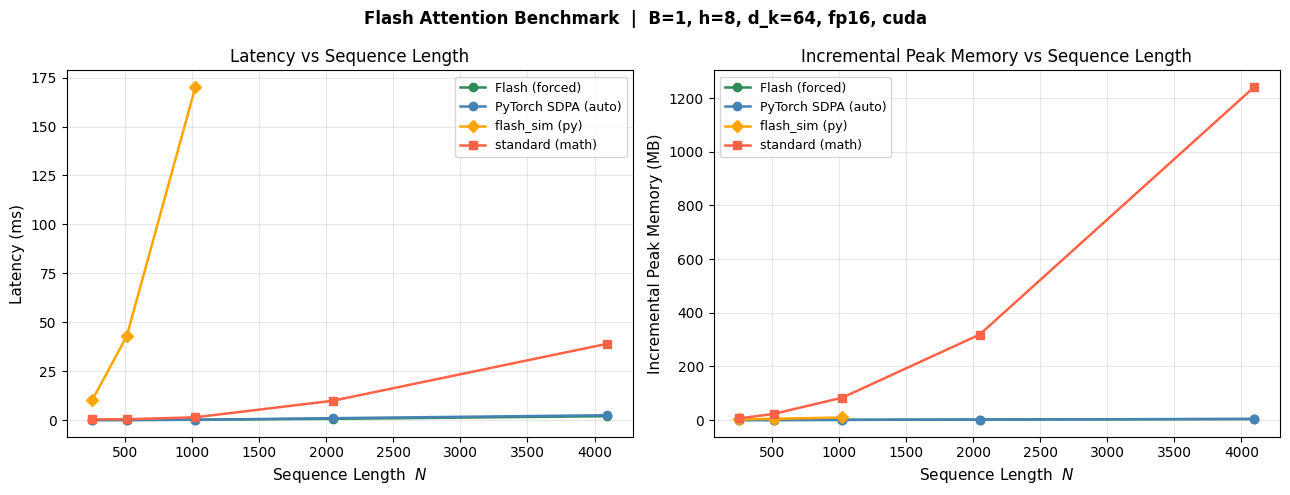

图像已保存至 results/03_benchmark_plot.png


In [8]:
import pandas as pd

df_bench = pd.DataFrame(all_records)
df_bench = df_bench[df_bench["status"] == "ok"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {
    "standard (math)": "tomato",
    "flash_sim (py)": "orange",
    "PyTorch SDPA (auto)": "steelblue",
    "Flash (forced)": "seagreen",
}
markers = {"standard (math)": "s", "flash_sim (py)": "D", "PyTorch SDPA (auto)": "o"}

for ax, metric, ylabel, title in [
    (axes[0], "latency_ms", "Latency (ms)", "Latency vs Sequence Length"),
    (axes[1], "memory_mb", "Incremental Peak Memory (MB)", "Incremental Peak Memory vs Sequence Length"),
]:
    for impl, grp in df_bench.groupby("impl"):
        g = grp.sort_values("seq_len")
        valid = g.dropna(subset=[metric])
        if valid.empty or valid[metric].isna().all():
            continue
        ax.plot(
            valid["seq_len"], valid[metric],
            marker=markers.get(impl, "o"),
            color=colors.get(impl),
            linewidth=1.8,
            label=impl,
        )
    ax.set_xlabel("Sequence Length  $N$", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title)
    if ax.lines:
        ax.legend(fontsize=9)
    elif metric == "memory_mb" and device == "cpu":
        ax.text(0.5, 0.5, "CUDA memory is not measured on CPU",
                ha="center", transform=ax.transAxes)
    ax.grid(alpha=0.3)

dtype_label = "fp16" if device == "cuda" else "fp32"
plt.suptitle(
    f"Flash Attention Benchmark  |  B={BATCH}, h={HEADS}, d_k={D_HEAD}, {dtype_label}, {device}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(results_dir / "03_benchmark_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/03_benchmark_plot.png")

In [9]:
# 加速比与显存节省分析
pivot_lat = df_bench.pivot_table(index="seq_len", columns="impl", values="latency_ms")
pivot_mem = df_bench.pivot_table(index="seq_len", columns="impl", values="memory_mb")

std_col  = "standard (math)"
sdpa_col = "Flash (forced)" if device == "cuda" else "PyTorch SDPA (auto)"

if std_col in pivot_lat.columns and sdpa_col in pivot_lat.columns:
    pivot_lat["speedup (standard / selected)"] = (
        pivot_lat[std_col] / pivot_lat[sdpa_col]
    )
    print(f"=== 延迟加速比：standard (math) / {sdpa_col} ===")
    print(pivot_lat[[std_col, sdpa_col, "speedup (standard / selected)"]]
          .to_string(float_format="{:.3f}".format))

else:
    print(f"缺少 {sdpa_col} 的成功结果，跳过延迟加速比。")

if std_col in pivot_mem.columns and sdpa_col in pivot_mem.columns:
    pivot_mem["mem_reduction (standard / selected)"] = (
        pivot_mem[std_col] / pivot_mem[sdpa_col].replace(0, np.nan)
    )
    print(f"\n=== 新增峰值显存比：standard (math) / {sdpa_col} ===")
    print(pivot_mem[[std_col, sdpa_col, "mem_reduction (standard / selected)"]]
          .to_string(float_format="{:.3f}".format))
else:
    print("缺少可比较的显存数据，跳过显存比值。")

=== 延迟加速比：standard (math) / Flash (forced) ===
impl     standard (math)  Flash (forced)  speedup (standard / selected)
seq_len                                                                
256                0.366           0.078                          4.712
512                0.441           0.062                          7.135
1024               1.451           0.210                          6.893
2048               9.887           0.660                         14.975
4096              39.018           1.993                         19.575

=== 新增峰值显存比：standard (math) / Flash (forced) ===
impl     standard (math)  Flash (forced)  mem_reduction (standard / selected)
seq_len                                                                      
256                6.818           0.271                               25.126
512               23.073           0.542                               42.595
1024              83.895           1.082                               77.510
2048     

**基准结果分析**

本轮在 WSL 中使用 RTX 4060 Laptop GPU，输入为 B=1、h=8、d_k=64、FP16，测量无因果掩码、关闭梯度和 dropout 的前向计算。Notebook 输出、图表与 `results/03_benchmark_flash_attention.json` 来自同一轮完整运行；下表根据该 JSON 整理。

| 序列长度 N | 标准延迟（ms） | Flash 延迟（ms） | 加速比 | 新增峰值显存（MB，标准 → Flash） |
|---|---:|---:|---:|---:|
| 256 | 0.366 | 0.078 | 4.71 倍 | 6.818 → 0.271 |
| 512 | 0.441 | 0.062 | 7.13 倍 | 23.073 → 0.542 |
| 1024 | 1.451 | 0.210 | 6.89 倍 | 83.895 → 1.082 |
| 2048 | 9.887 | 0.660 | 14.97 倍 | 318.784 → 2.164 |
| 4096 | 39.018 | 1.993 | 19.57 倍 | 1241.547 → 4.326 |

N=4096 时，强制 Flash 的延迟为 1.993 ms，标准 math 为 39.018 ms，加速比为 19.57 倍。新增峰值显存由 1241.547 MB 降至 4.326 MB，减少约 99.65%。这些指标对应本机、这组输入和前向范围，不包含已有输入及整个模型的其他开销。

Python 分块演示包含循环、多次小算子调用和 FP32 转换，其耗时不能代表融合 Flash kernel。自动 SDPA 的实际 backend 没有通过 profiler 记录，因此仍以 auto 标记。本轮测点没有独立重复实验的置信区间，短延迟的小幅差异需要进一步确认。


In [10]:
# 有限序列范围内的增长趋势，不据此判定算法复杂度
for impl, grp in df_bench.groupby('impl'):
    valid = grp.dropna(subset=['latency_ms']).sort_values('seq_len')
    if len(valid) >= 3:
        slope, intercept = np.polyfit(np.log(valid['seq_len']), np.log(valid['latency_ms']), 1)
        print(f'{impl}: log-log 拟合斜率 {slope:.2f}')
print('固定头维度时，全注意力计算量随 N² 增长；有限范围的延迟斜率也受启动开销和并行度影响。')

Flash (forced): log-log 拟合斜率 1.28
PyTorch SDPA (auto): log-log 拟合斜率 1.79
flash_sim (py): log-log 拟合斜率 2.02
standard (math): log-log 拟合斜率 1.80
固定头维度时，全注意力计算量随 N² 增长；有限范围的延迟斜率也受启动开销和并行度影响。


**增长趋势分析**

根据本轮 JSON 中成功的测点，log-log 拟合斜率为：

- `Flash (forced)`：1.28。
- `PyTorch SDPA (auto)`：1.79。
- `flash_sim (py)`：2.02。
- `standard (math)`：1.80。

它们描述有限序列范围内的实测延迟趋势，也受启动开销、GPU 利用率和算子调度影响。不能把接近 1 的延迟斜率解释为 FlashAttention 的计算量变成 O(N)；固定头维度时，全注意力计算量仍随 N² 增长。


## 5 反向传播：重计算策略

### 5.1 标准反向传播

先按 01 的计算顺序写出梯度。记 $dO=\partial L/\partial O$，不使用 dropout 时：
$$
dV=A^\top dO,\qquad dA=dO V^\top,
$$
$$
D=\text{rowsum}(dA\odot A),\qquad
dS=A\odot(dA-D),
$$
$$
dQ=\frac{dS K}{\sqrt{d_k}},\qquad
dK=\frac{dS^\top Q}{\sqrt{d_k}}.
$$
$D$ 沿整行求和，并沿列广播。通常需要保存 $A$；是否同时保存 $S$ 取决于实现，但只保存 $A$ 也有 $O(N^2)$ 开销。

### 5.2 FlashAttention 如何重计算？

前向保存 $Q,K,V,O$ 和每行的归一化统计量。2022 论文保存 $(m,\ell)$；也可以用一个 log-sum-exp 值表示二者，这也是 v2 的改进之一：
$$
\text{lse}_a=m_a+\ln\ell_a=\ln\sum_b e^{S_{ab}}.
$$
这里 $a,b$ 是 token 位置，$c$ 是特征通道，$i,j$ 仍表示块编号。下面为了简化代码使用 lse，2022 论文原本保存的是 $m,\ell$。反向时按块重算：
$$
A_{ab}=\exp(S_{ab}-\text{lse}_a).
$$
这里要用整行的 lse。直接对 $S_{ij}$ 做 softmax，会只用当前块的 key 作为分母。行修正量 $D$ 也沿整行计算；利用 $O=AV$ 可以把它写成：
$$
D_a=\sum_b dA_{ab}A_{ab}
=\sum_c dO_{ac}O_{ac}.
$$

```text
初始化 dQ, dK, dV 为 0；计算 D = rowsum(dO ⊙ O)
for 每个 K/V 块 j:
    加载 Kj, Vj
    for 每个 Q 块 i:
        加载 Qi, dOi, lse_i, Di
        重算 Sij = Qi Kjᵀ / sqrt(d_k)（有掩码时同样应用）
        Aij = exp(Sij - lse_i)
        dVj += Aijᵀ dOi
        dAij = dOi Vjᵀ
        dSij = Aij ⊙ (dAij - Di)
        dQi += dSij Kj / sqrt(d_k)
        dKj += dSijᵀ Qi / sqrt(d_k)
```

### 5.3 显存为什么是线性的？

保存 $Q,K,V,O$ 共 $4Nd_k$ 个元素，lse 共 $N$ 个元素。梯度也只需 $O(Nd_k)$ 空间，局部 $B_r\times B_c$ 中间块计算后丢弃，不保存完整 $S,A,dA,dS$。

所以该注意力算子的前向与反向所需显存为 $O(Nd_k+N)$；固定 $d_k$ 时为 $O(N)$。多头、多样本乘以 $Bh$。这里统计的是注意力算子；整个模型还需要其他层的激活、参数和优化器状态。

重计算多做了一部分运算，换来了更少的保存和读取。下面在普通和因果两种模式下重算权重和梯度，并与 autograd 对照。函数也支持 FP16/BF16 输入：中间计算用 FP32，最后转换回输入类型。半精度输出本身的舍入仍会影响 $D$ 的精度。

In [11]:
@torch.no_grad()
def recompute_backward(Q, K, V, O, dO, lse, block_r=7, block_c=5, causal=False):
    """用前向保存的 O、lse 重算分块梯度，不建立 autograd 计算图。"""
    validate_attention_inputs(Q, K, V, block_r, block_c)
    for name, tensor, shape in [("O", O, Q.shape), ("dO", dO, Q.shape),
                                ("lse", lse, Q.shape[:-1])]:
        if tensor.shape != shape or tensor.device != Q.device or not tensor.is_floating_point():
            raise ValueError(f"{name} 的形状、设备或数据类型与前向状态不匹配")

    output_dtype = Q.dtype
    work_dtype = torch.float64 if Q.dtype == torch.float64 else torch.float32
    Q, K, V, O, dO, lse = [x.to(work_dtype) for x in (Q, K, V, O, dO, lse)]
    D = (dO * O).sum(dim=-1, keepdim=True)
    dQ, dK, dV = torch.zeros_like(Q), torch.zeros_like(K), torch.zeros_like(V)
    scale = 1 / math.sqrt(Q.size(-1))
    N = Q.size(-2)

    for j0 in range(0, N, block_c):
        j1 = min(j0 + block_c, N)
        Kj, Vj = K[..., j0:j1, :], V[..., j0:j1, :]
        for i0 in range(0, N, block_r):
            i1 = min(i0 + block_r, N)
            if causal and j0 >= i1:
                continue
            Qi, dOi = Q[..., i0:i1, :], dO[..., i0:i1, :]
            Sij = block_scores(Qi, Kj, i0, j0, scale, causal)
            # 分母来自整行，而不是当前分数块。
            Aij = torch.exp(Sij - lse[..., i0:i1, None])
            dAij = dOi @ Vj.transpose(-2, -1)
            dSij = Aij * (dAij - D[..., i0:i1, :])
            dV[..., j0:j1, :] += Aij.transpose(-2, -1) @ dOi
            dQ[..., i0:i1, :] += (dSij @ Kj) * scale
            dK[..., j0:j1, :] += (dSij.transpose(-2, -1) @ Qi) * scale
    return tuple(grad.to(output_dtype) for grad in (dQ, dK, dV))

torch.manual_seed(5)
Qg = torch.randn(1, 2, 17, 16, device=device, requires_grad=True)
Kg, Vg = torch.randn_like(Qg, requires_grad=True), torch.randn_like(Qg, requires_grad=True)
dO = torch.randn_like(Qg)
for causal in (False, True):
    output_ref = run_standard(Qg, Kg, Vg, causal)
    grads_ref = torch.autograd.grad(output_ref, (Qg, Kg, Vg), dO)
    O, ell, m = flash_attention_v1_forward(Qg.detach(), Kg.detach(), Vg.detach(), 7, 5, causal)
    grads = recompute_backward(Qg, Kg, Vg, O, dO, m + ell.log(), causal=causal)
    torch.testing.assert_close(O, output_ref, atol=1e-5, rtol=1e-4)
    for name, actual, expected in zip(("dQ", "dK", "dV"), grads, grads_ref):
        torch.testing.assert_close(actual, expected, atol=1e-5, rtol=1e-4)
        print(f"causal={causal}, {name}: 最大误差 {(actual - expected).abs().max().item():.2e}")

causal=False, dQ: 最大误差 4.77e-07
causal=False, dK: 最大误差 5.66e-07
causal=False, dV: 最大误差 3.58e-07
causal=True, dQ: 最大误差 1.13e-06
causal=True, dK: 最大误差 9.39e-07
causal=True, dV: 最大误差 4.77e-07


/home/zyl/.venvs/efficient-attention-flash/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


**梯度结果分析**

普通模式下，$dQ,dK,dV$ 的最大误差约为 $3.6\times10^{-7}$ 到 $5.7\times10^{-7}$；因果模式下，最大误差为 $1.13\times10^{-6}$。所有梯度都通过了与 autograd 的对照检查，说明在这组输入上，通过重新计算局部权重，也能得到接近标准方法的梯度。

这支持了“前向少存一些中间结果，反向需要时再算”的思路。当前代码检查的是梯度正确性，没有测量反向耗时或实际峰值显存，因此还不能单凭这些误差判断训练加速了多少。

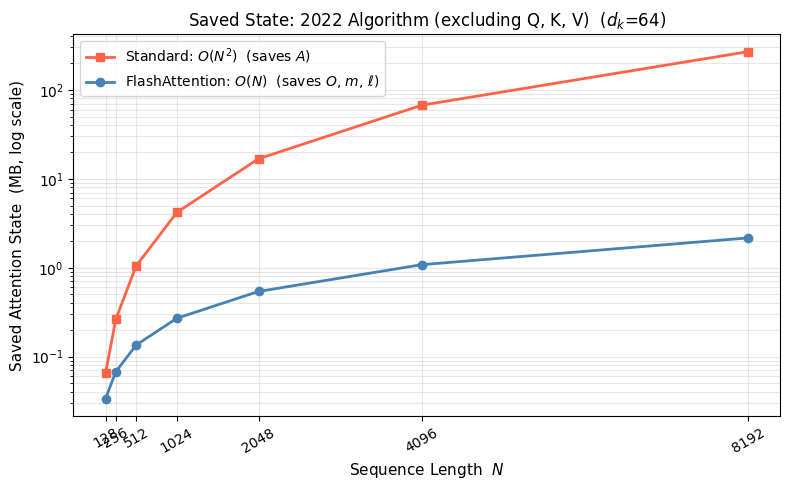

图像已保存至 results/03_backward_memory.png


In [12]:
# 显存随序列长度的增长：O(N²) vs O(N) 可视化

d_k_mem = 64
seq_mems = [128, 256, 512, 1024, 2048, 4096, 8192]

# 标准注意力反向：保存 A(N²) 个 fp32 元素
standard_mem_mb = [N**2 * 4 / 1e6 for N in seq_mems]
# 2022 论文反向：保存 O(N*d_k)、m(N)、ell(N)，不计共同的 Q、K、V。
flash_mem_mb = [(N * d_k_mem + 2 * N) * 4 / 1e6 for N in seq_mems]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(seq_mems, standard_mem_mb, marker="s", color="tomato",
            linewidth=2, label=r"Standard: $O(N^2)$  (saves $A$)")
ax.semilogy(seq_mems, flash_mem_mb, marker="o", color="steelblue",
            linewidth=2, label=r"FlashAttention: $O(N)$  (saves $O$, $m$, $\ell$)")

ax.set_xlabel("Sequence Length  $N$", fontsize=11)
ax.set_ylabel("Saved Attention State  (MB, log scale)", fontsize=11)
ax.set_title(f"Saved State: 2022 Algorithm (excluding Q, K, V)  ($d_k$={d_k_mem})")
ax.set_xticks(seq_mems)
ax.set_xticklabels([str(n) for n in seq_mems], rotation=30)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(results_dir / "03_backward_memory.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/03_backward_memory.png")

**图像分析**

本图按单样本、单头、FP32 估算反向需要保存的注意力状态，并排除了共同的 $Q,K,V$。$N=4096$ 时，标准方法保存权重矩阵约需 67.11 MB，而 FlashAttention 保存输出和行统计量约需 1.08 MB。长度翻倍到 8192 后，前者约增至 268.44 MB，后者约增至 2.16 MB。

可以看到，标准方法的保存量约增至四倍，FlashAttention 约增至两倍，长序列时差距进一步拉大。这张图由公式计算，帮助理解重计算为什么能节省存储；它与第 4 节的多头、FP16 前向实测采用不同设置，数值不能直接对比，也不代表完整训练的显存占用。

## 6 拓展：FlashAttention-2

FlashAttention-2 是后续工作，预印本发表于 2023 年，会议版为 ICLR 2024。这里补充它的几个主要思路，试图理解这个方向的后续进展；它继续计算相同的注意力。

### 6.1 外层遍历 $Q$ 块

与 Algorithm 1 的循环相比，外层遍历 $Q$ 块、内层遍历 $K/V$ 块，可以把当前行块的输出累积量保留到内循环结束，再一次写回。每个 $Q$ 块独立计算，便于沿序列维度分配给多个 thread block。

这样能减少 $O$ 的写回，也便于让多个 $Q$ 块并行。相应地，不同 $Q$ 块会重复读取 $K,V$，实际 kernel 还要安排好数据复用。

### 6.2 最后再归一化

沿用 02 的未归一化输出 $\tilde O_i$，更新行最大值后，直接以这个新基准计算当前块的指数：
$$
m_i^{\text{new}}=\max(m_i^{\text{old}},\operatorname{rowmax}(S_{ij})),\qquad
\alpha_i=e^{m_i^{\text{old}}-m_i^{\text{new}}},\qquad
\bar A_{ij}=\exp(S_{ij}-m_i^{\text{new}}).
$$
$\bar A_{ij}$ 仍未归一化，但它已经使用更新后的整行最大值。按行广播后：
$$
\ell_i^{\text{new}}=\alpha_i\ell_i^{\text{old}}+\operatorname{rowsum}(\bar A_{ij}),\qquad
\tilde O_i^{\text{new}}=\alpha_i\tilde O_i^{\text{old}}+\bar A_{ij}V_j.
$$
处理完所有 $K/V$ 块后，再算 $O_i=\tilde O_i/\ell_i$。这样减少了每步的输出缩放和除法，两次矩阵乘的计算量没有减半。v2 还保存最终 lse 供反向使用；下面代码只演示前向输出，不实现它的 CUDA 并行调度。

### 6.3 因果注意力跳过未来块

对于 query 位置区间 $[i_0,i_1)$、key 区间 $[j_0,j_1)$：

- $j_0\ge i_1$：全部是未来位置，跳过该块。
- $j_1-1\le i_0$：全部可见，不需要逐元素掩码。
- 其余块：逐元素遮蔽 $b>a$ 的位置。

长序列、固定块大小时，跳过的上三角块接近一半，因果注意力的矩阵乘工作量约为全注意力的一半。这来自因果结构，并非 v2 独有，也不保证延迟减半。

### 6.4 更合理的并行分工

当 $Bh$ 较小时，只按 batch 和 head 分配任务可能无法充分利用 GPU。v2 还按 $Q$ 行块分配任务，让单个 head 也能在多个 thread block 上并行。

在一个 thread block 内，v2 让不同 warp 负责不同 $Q$ 行，复用 $K,V$，减少通过共享内存合并输出的开销。这里的序列并行发生在单张 GPU 上。

下面把循环顺序和输出更新的变化写成 PyTorch 代码。随后的小规模测速，可以看到这份代码的开销；真实 kernel 的收益还需要单独测量。

来源：[FlashAttention-2，§3](https://arxiv.org/html/2307.08691v1)。

In [13]:
def flash_attention_v2_forward(Q, K, V, block_r=64, block_c=64, causal=False):
    """按 Q 块遍历，先累积未归一化输出，最后再除以行分母。"""
    validate_attention_inputs(Q, K, V, block_r, block_c)
    output_dtype = Q.dtype
    if Q.dtype in (torch.float16, torch.bfloat16):
        Q, K, V = Q.float(), K.float(), V.float()
    N, d_k = Q.shape[-2:]
    scale = 1 / math.sqrt(d_k)
    O = torch.zeros_like(Q)

    for i0 in range(0, N, block_r):
        i1 = min(i0 + block_r, N)
        Qi = Q[..., i0:i1, :]
        mi = Qi.new_full(Qi.shape[:-1], float("-inf"))
        ell_i = Qi.new_zeros(Qi.shape[:-1])
        Oi_unnorm = torch.zeros_like(Qi)

        for j0 in range(0, N, block_c):
            # 后面的 key 块也全在未来，可以直接结束当前 Q 块。
            if causal and j0 >= i1:
                break
            Kj, Vj = K[..., j0:j0 + block_c, :], V[..., j0:j0 + block_c, :]
            Sij = block_scores(Qi, Kj, i0, j0, scale, causal)
            mi_new = torch.maximum(mi, Sij.amax(dim=-1))
            alpha = torch.exp(mi - mi_new)
            # 直接用更新后的行最大值，计算当前块的未归一化指数。
            A_rescaled = torch.exp(Sij - mi_new.unsqueeze(-1))
            ell_i = alpha * ell_i + A_rescaled.sum(dim=-1)
            Oi_unnorm = alpha.unsqueeze(-1) * Oi_unnorm + A_rescaled @ Vj
            mi = mi_new

        O[..., i0:i1, :] = Oi_unnorm / ell_i.unsqueeze(-1)
    return O.to(output_dtype)

torch.manual_seed(0)
Qv2 = torch.randn(1, 2, 65, 32, device=device)
Kv2, Vv2 = torch.randn_like(Qv2), torch.randn_like(Qv2)
with torch.no_grad():
    for causal in (False, True):
        reference = run_standard(Qv2, Kv2, Vv2, causal)
        for block_r, block_c in [(16, 32), (32, 16), (64, 64)]:
            output = flash_attention_v2_forward(Qv2, Kv2, Vv2, block_r, block_c, causal)
            torch.testing.assert_close(output, reference, atol=1e-5, rtol=1e-4)
            print(f"causal={causal}, Br={block_r:3d}, Bc={block_c:3d}: "
                  f"最大误差 {(output - reference).abs().max().item():.2e}")

# 两份前向代码也能通过 autograd 对照梯度。
for causal in (False, True):
    Q_test, K_test, V_test = [x.detach().requires_grad_() for x in (Qg, Kg, Vg)]
    expected = torch.autograd.grad(run_standard(Q_test, K_test, V_test, causal),
                                   (Q_test, K_test, V_test), dO)
    for fn in (flash_attention_v1_forward, flash_attention_v2_forward):
        output = fn(Q_test, K_test, V_test, 7, 5, causal)
        if isinstance(output, tuple):
            output = output[0]
        actual = torch.autograd.grad(output, (Q_test, K_test, V_test), dO)
        for grad, reference in zip(actual, expected):
            torch.testing.assert_close(grad, reference, atol=1e-5, rtol=1e-4)

causal=False, Br= 16, Bc= 32: 最大误差 3.58e-07
causal=False, Br= 32, Bc= 16: 最大误差 4.77e-07
causal=False, Br= 64, Bc= 64: 最大误差 5.07e-07
causal=True, Br= 16, Bc= 32: 最大误差 5.66e-07
causal=True, Br= 32, Bc= 16: 最大误差 4.77e-07
causal=True, Br= 64, Bc= 64: 最大误差 4.77e-07


**结果分析**

v2 前向演示在普通和因果模式下的最大误差约为 $3.6\times10^{-7}$ 到 $5.7\times10^{-7}$，全部通过检查。后面的 v1、v2 梯度对照代码也执行到了结束，没有出现断言失败。这说明在本次输入上，改变循环顺序并把归一化放到最后，仍可以保持输出和梯度的一致性。

In [14]:
# v1 vs v2 延迟对比（普通 PyTorch 实现的延迟）
import torch.utils.benchmark as benchmark

@torch.no_grad()
def bench_fn(fn, *args, n=15):
    for _ in range(3):
        fn(*args)
    t = benchmark.Timer(stmt="fn(*args)", globals={"fn": fn, "args": args}, num_threads=1)
    return t.timeit(n).mean * 1e3  # ms


print("=== 两份 PyTorch 实现的前向延迟 ===")
print(f"{'N':>6}  {'v1 (ms)':>10}  {'v2 (ms)':>10}  {'v2/v1':>8}")
print("-"* 40)

bench_seq = [64, 128, 256]  # Python 演示只测小序列，避免大量小算子调用
for N_b in bench_seq:
    torch.manual_seed(0)
    Qb = torch.randn(1, 4, N_b, 64, device=device)
    Kb = torch.randn(1, 4, N_b, 64, device=device)
    Vb = torch.randn(1, 4, N_b, 64, device=device)

    t_v1 = bench_fn(lambda q,k,v: flash_attention_v1_forward(q, k, v, block_r=64, block_c=64), Qb, Kb, Vb)
    t_v2 = bench_fn(lambda q,k,v: flash_attention_v2_forward(q, k, v, block_r=64, block_c=64), Qb, Kb, Vb)
    ratio = t_v2 / t_v1
    print(f"{N_b:>6}  {t_v1:>10.3f}  {t_v2:>10.3f}  {ratio:>8.3f}")

print()
print("这是普通 PyTorch 代码的耗时，包含循环和算子调度；真实 FlashAttention 的性能请看融合 backend 的测量。")

=== 两份 PyTorch 实现的前向延迟 ===
     N     v1 (ms)     v2 (ms)     v2/v1
----------------------------------------
    64       1.537       0.703     0.458


   128       4.651       3.535     0.760


   256      10.081       9.443     0.937

这是普通 PyTorch 代码的耗时，包含循环和算子调度；真实 FlashAttention 的性能请看融合 backend 的测量。


**延迟结果分析**

本轮普通 PyTorch 实现的前向计时如下，数值来自上方刚执行的输出：

| N | v1（ms） | v2（ms） | v2/v1 |
|---|---:|---:|---:|
| 64 | 1.537 | 0.703 | 0.458 |
| 128 | 4.651 | 3.535 | 0.760 |
| 256 | 10.081 | 9.443 | 0.937 |

v2/v1 小于 1 表示 v2 在该测点更快。这里使用小序列和 FP32，只观察计算顺序、循环与算子调度的差异；没有实现真实 CUDA kernel 的并行分工，这些比例不能当作论文中 FlashAttention-2 的加速比。


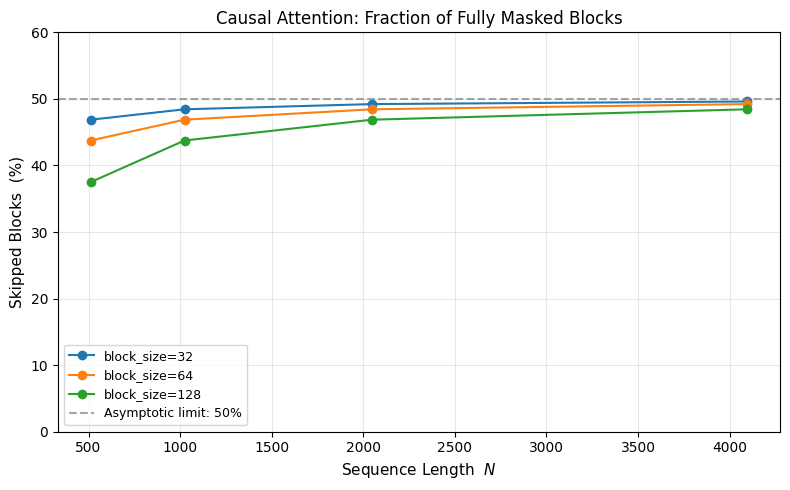

图像已保存至 results/03_causal_skip.png


In [15]:
# 只统计因果掩码中完全位于未来的块；v1、v2 都可以跳过它们
block_sizes_vis = [32, 64, 128]
seq_lens_vis    = [512, 1024, 2048, 4096]

fig, ax = plt.subplots(figsize=(8, 5))

for bs in block_sizes_vis:
    skipped_fracs = []
    for N_vis in seq_lens_vis:
        Tr = math.ceil(N_vis / bs)
        Tc = math.ceil(N_vis / bs)
        total_blocks = Tr * Tc
        skipped = 0
        for i in range(Tr):
            i1 = min((i + 1) * bs, N_vis)
            for j in range(Tc):
                j0 = j * bs
                if j0 >= i1:   # 全遮蔽块的跳过条件
                    skipped += Tc - j  # 后续所有块都跳过
                    break
        skipped_fracs.append(skipped / total_blocks * 100)
    ax.plot(seq_lens_vis, skipped_fracs, marker="o", label=f"block_size={bs}")

ax.axhline(50, linestyle="--", color="gray", alpha=0.7, label="Asymptotic limit: 50%")
ax.set_xlabel("Sequence Length  $N$", fontsize=11)
ax.set_ylabel("Skipped Blocks  (%)", fontsize=11)
ax.set_title("Causal Attention: Fraction of Fully Masked Blocks")
ax.legend(fontsize=9)
ax.set_ylim(0, 60)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "03_causal_skip.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/03_causal_skip.png")

**图像分析**

序列越长，完全位于未来、可以跳过的块比例越接近 50%。例如，块大小为 64 时，$N=512$ 可跳过 43.75% 的块，$N=4096$ 时约为 49.22%。这与因果注意力只关注当前位置及之前位置的规则一致。

同一长度下，较小的块可以更细地划分对角线附近的区域，因此可完全跳过的块比例更高。但小块也会增加块数和调度开销，不能由此判断块越小就越快。本图统计的是可跳过的块比例，没有测量耗时；接近一半的块被跳过，也不保证延迟减少一半。

## 7 小结

本节通过分块前向、因果掩码和梯度对照，复现了 FlashAttention 的主要计算思路。前向和梯度对照均通过了代码中的容差检查；具体输入精度和误差见对应单元输出。

本轮在 WSL 中完整运行并同步保存了输出、图表与 JSON。N=4096 时，强制 Flash 相比标准 math 的前向加速比为 19.57 倍，新增峰值显存由 1241.547 MB 降至 4.326 MB。该观察限于本机、当前输入和前向测量。

Python 分块代码帮助我们理解公式，但循环、算子调用和精度转换会增加耗时。v1/v2 演示的实际延迟见前面的表；真实 FlashAttention-2 还包含本示例没有实现的 GPU 并行优化，不能把这里的变化直接当作论文实现的性能。

这次实验没有复现论文中的完整模型训练，也没有实测反向峰值显存。能够得出的结论是：分块和重计算在保持注意力数学结果的基础上减少中间量保存，而本机 SDPA Flash 前向表现出明显的速度和显存优势。全注意力计算量仍随 $N^2$ 增长，有限长度的耗时拟合不能改变这一点。

接下来在 [04 · INT8 量化](04_int8_quantization.ipynb) 中，看看降低存储位宽会怎样影响精度和性能。

**参考文献**

- [FlashAttention，NeurIPS 2022，本地 PDF](https://arxiv.org/abs/2205.14135)
- [FlashAttention-2，ICLR 2024](https://arxiv.org/abs/2307.08691)
- [Online normalizer calculation for softmax，2018](https://arxiv.org/abs/1805.02867)
- [PyTorch SDPA 文档](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)